In [16]:
'''
ICS1501 Applied Optimization Techniques
UNIT 2 – Tutorial Problems
Name: Amsavarthini S
Reg no:3122247001004
'''

'\nICS1501 Applied Optimization Techniques\nUNIT 2 – Tutorial Problems\nName: Amsavarthini S\nReg no:3122247001004\n'

Final x = 2.9999999992361115
Minimum value = 5.835256526607744e-19


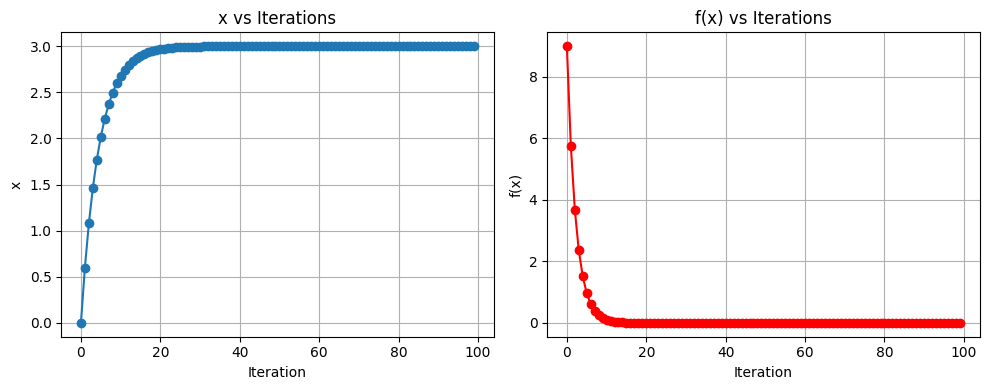

In [17]:
'''
Q1: Gradient Descent – 1D Minimization Use gradient descent to minimize the function
f(x)=(x - 3) ** 2
•Write a Python function to implement gradient descent.
• Use a suitable learning rate and initial value.
• Run for 100 iterations.
• Plot how x and f(x) change over time.
'''

import numpy as np
import matplotlib.pyplot as plt

# Function
def f(x):
    return (x - 3)**2

# Gradient of the function
def gradient(x):
    return 2 * (x - 3)

# Gradient Descent
def gradient_descent(initial_x, learning_rate, iterations):
    x = initial_x

    x_history = []
    loss_history = []

    for i in range(iterations):
        x_history.append(x)
        loss_history.append(f(x))

        grad = gradient(x)

        # Update x
        x = x - learning_rate * grad

    return x_history, loss_history

# Parameters
initial_x = 0
learning_rate = 0.1
iterations = 100

# Run Gradient Descent
x_values, loss_values = gradient_descent(initial_x, learning_rate, iterations)

print("Final x =", x_values[-1])
print("Minimum value =", loss_values[-1])

# Plot x over iterations
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(x_values, marker='o')
plt.title("x vs Iterations")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.grid(True)

# Plot f(x) over iterations
plt.subplot(1,2,2)
plt.plot(loss_values, marker='o', color='red')
plt.title("f(x) vs Iterations")
plt.xlabel("Iteration")
plt.ylabel("f(x)")
plt.grid(True)

plt.tight_layout()
plt.show()

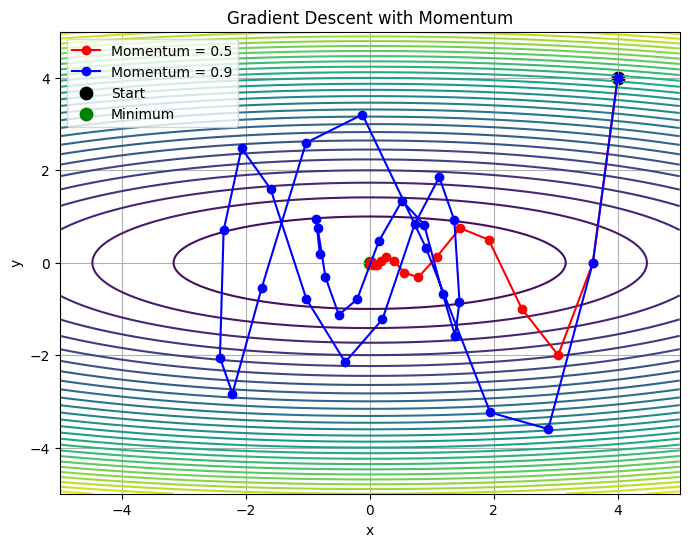

In [18]:
'''
Q2:Momentum – 2D Function Minimization Apply gradient descent with momentum to minimize the function
f(x)=x**2 + 10 * y**2
• Implement momentum manually.
• Try different momentum values (e.g., 0.5, 0.9).
• Visualize the optimization path using a contour plot.
'''

import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return x**2 + 10*y**2

def gradient(x, y):
    df_dx = 2 * x
    df_dy = 20 * y
    return np.array([df_dx, df_dy])

# Gradient Descent with Momentum
def momentum_gradient_descent(start, learning_rate, momentum, iterations):
    point = np.array(start, dtype=float)

    # Initialize velocity
    velocity = np.zeros(2)

    # Store optimization path
    path = [point.copy()]

    for i in range(iterations):
        grad = gradient(point[0], point[1])

        # Momentum update
        velocity = momentum * velocity - learning_rate * grad

        # Update parameters
        point = point + velocity

        path.append(point.copy())

    return np.array(path)

start = [4, 4]
learning_rate = 0.05
iterations = 30

path1 = momentum_gradient_descent(start, learning_rate, 0.5, iterations)
path2 = momentum_gradient_descent(start, learning_rate, 0.9, iterations)

x = np.linspace(-5, 5, 300)
y = np.linspace(-5, 5, 300)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

plt.figure(figsize=(8,6))
plt.contour(X, Y, Z, levels=30, cmap='viridis')

plt.plot(path1[:,0], path1[:,1], 'ro-', label='Momentum = 0.5')
plt.plot(path2[:,0], path2[:,1], 'bo-', label='Momentum = 0.9')

plt.scatter(start[0], start[1], color='black', s=80, label='Start')
plt.scatter(0, 0, color='green', s=80, label='Minimum')

plt.title("Gradient Descent with Momentum")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

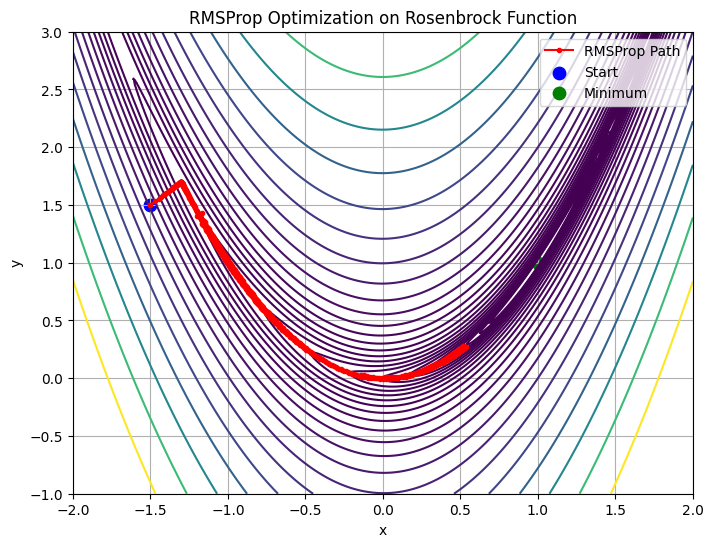

In [19]:
'''
Q3:RMSProp – Rosenbrock Function Minimize the Rosenbrock function using RMSProp optimizer.
f(x,y)=(1 - x)**2 + 100 * (y - x**2)**2

'''

import numpy as np
import matplotlib.pyplot as plt

# Rosenbrock function
def f(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

# Gradient of Rosenbrock function
def gradient(x, y):
    df_dx = -2 * (1 - x) - 400 * x * (y - x**2)
    df_dy = 200 * (y - x**2)
    return np.array([df_dx, df_dy])

# RMSProp Optimizer
def rmsprop(start, learning_rate, beta, epsilon, iterations):
    point = np.array(start, dtype=float)
    s = np.zeros(2)

    path = [point.copy()]

    for i in range(iterations):
        grad = gradient(point[0], point[1])
        # RMSProp update
        s = beta * s + (1 - beta) * (grad ** 2)
        point = point - learning_rate * grad / (np.sqrt(s) + epsilon)
        path.append(point.copy())
    return np.array(path)

# Parameters
start = [-1.5, 1.5]
learning_rate = 0.01
beta = 0.9
epsilon = 1e-8
iterations = 500

# Run RMSProp
path = rmsprop(start, learning_rate, beta, epsilon, iterations)

x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

plt.figure(figsize=(8,6))
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 25), cmap='viridis')
plt.plot(path[:,0], path[:,1], 'r.-', label='RMSProp Path')
plt.scatter(start[0], start[1], color='blue', s=80, label='Start')
plt.scatter(1, 1, color='green', s=80, label='Minimum')
plt.xlabel("x")
plt.ylabel("y")
plt.title("RMSProp Optimization on Rosenbrock Function")
plt.legend()
plt.grid(True)
plt.show()

C:\Users\91934\AppData\Local\Temp\ipykernel_8184\2814918909.py:61: RuntimeWarning: invalid value encountered in scalar divide
  beta = np.dot(new_grad, new_grad) / (np.dot(grad, grad) + 1e-8)


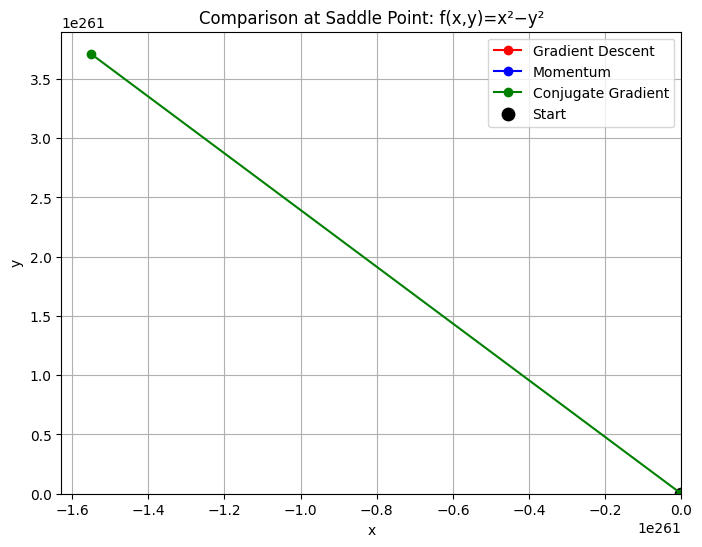

In [20]:
'''
Q3: Comparison – Behavior at a Saddle Point Minimize the function
using Gradient Descent, Momentum, and Conjugate Gradient.
f(x,y)=x**2 - y**2
• Start at the point (1, 1).
• Use the same number of iterations and similar learning rate.
Plot and compare the optimization paths for each method.
'''

import numpy as np
import matplotlib.pyplot as plt

# Function
def f(x, y):
    return x**2 - y**2

# Gradient
def gradient(x, y):
    return np.array([2*x, -2*y])

def gradient_descent(start, lr, iterations):
    point = np.array(start, dtype=float)
    path = [point.copy()]

    for i in range(iterations):
        grad = gradient(point[0], point[1])
        point = point - lr * grad
        path.append(point.copy())

    return np.array(path)

def momentum(start, lr, beta, iterations):
    point = np.array(start, dtype=float)
    velocity = np.zeros(2)

    path = [point.copy()]

    for i in range(iterations):
        grad = gradient(point[0], point[1])

        velocity = beta * velocity - lr * grad
        point = point + velocity

        path.append(point.copy())

    return np.array(path)

def conjugate_gradient(start, lr, iterations):
    point = np.array(start, dtype=float)

    grad = gradient(point[0], point[1])
    direction = -grad

    path = [point.copy()]

    for i in range(iterations):
        point = point + lr * direction

        new_grad = gradient(point[0], point[1])

        beta = np.dot(new_grad, new_grad) / (np.dot(grad, grad) + 1e-8)

        direction = -new_grad + beta * direction

        grad = new_grad

        path.append(point.copy())

    return np.array(path)

# Parameters
start = [1, 1]
learning_rate = 0.1
iterations = 20

gd_path = gradient_descent(start, learning_rate, iterations)
mom_path = momentum(start, learning_rate, 0.9, iterations)
cg_path = conjugate_gradient(start, learning_rate, iterations)

x = np.linspace(-4, 4, 400)
y = np.linspace(-4, 4, 400)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

plt.figure(figsize=(8,6))
plt.contour(X, Y, Z, levels=30, cmap='viridis')

plt.plot(gd_path[:,0], gd_path[:,1], 'ro-', label='Gradient Descent')
plt.plot(mom_path[:,0], mom_path[:,1], 'bo-', label='Momentum')
plt.plot(cg_path[:,0], cg_path[:,1], 'go-', label='Conjugate Gradient')

plt.scatter(start[0], start[1], color='black', s=80, label='Start')
plt.title("Comparison at Saddle Point: f(x,y)=x²−y²")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
'''
Additional question: Implement Your Own Optimizer Class (No Packages)
'''

import numpy as np

# Optimizer Class
class MyOptimizer:
    def __init__(self, learning_rate=0.1):
        self.lr = learning_rate

    def step(self, params, grads):
        # Gradient Descent Update
        params = params - self.lr * grads
        return params


# Function: f(x,y) = x² + y²
def loss(params):
    x, y = params
    return x**2 + y**2


# Gradient
def gradient(params):
    x, y = params
    return np.array([2*x, 2*y])


# Initial Point
params = np.array([4.0, 3.0])

optimizer = MyOptimizer(learning_rate=0.1)

print("Iteration\t x\t\t y\t\t Loss")

for i in range(20):
    grads = gradient(params)
    params = optimizer.step(params, grads)

    print(f"{i+1}\t\t {params[0]:.4f}\t {params[1]:.4f}\t {loss(params):.4f}")

print("\nMinimum Point:", params)

Iteration	 x		 y		 Loss
1		 3.2000	 2.4000	 16.0000
2		 2.5600	 1.9200	 10.2400
3		 2.0480	 1.5360	 6.5536
4		 1.6384	 1.2288	 4.1943
5		 1.3107	 0.9830	 2.6844
6		 1.0486	 0.7864	 1.7180
7		 0.8389	 0.6291	 1.0995
8		 0.6711	 0.5033	 0.7037
9		 0.5369	 0.4027	 0.4504
10		 0.4295	 0.3221	 0.2882
11		 0.3436	 0.2577	 0.1845
12		 0.2749	 0.2062	 0.1181
13		 0.2199	 0.1649	 0.0756
14		 0.1759	 0.1319	 0.0484
15		 0.1407	 0.1056	 0.0309
16		 0.1126	 0.0844	 0.0198
17		 0.0901	 0.0676	 0.0127
18		 0.0721	 0.0540	 0.0081
19		 0.0576	 0.0432	 0.0052
20		 0.0461	 0.0346	 0.0033

Minimum Point: [0.04611686 0.03458765]
